In [1]:
import deepchem as dc
import pickle

with open("../models/dataset_split.pkl", "rb") as f:
    train_dataset, valid_dataset, test_dataset, transformers = pickle.load(f)

metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading material featurizer, missing a dependency. No module named 'ase'


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers.models.roberta.tokenization_roberta_fast'
cannot import name 'Chemberta' from 'deepchem.models.torch_models' (/Users/sohanmulamalla/Desktop/Projects/soluscope-ai/venv/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/Users/sohanmulamalla/Desktop/Projects/soluscope-ai/venv/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

models = {
    "Random Forest": dc.models.SklearnModel(RandomForestRegressor(n_estimators=100)),
    "SVR": dc.models.SklearnModel(SVR()),
    "Ridge Regression": dc.models.SklearnModel(Ridge()),
    "Neural Net (MultitaskRegressor)": dc.models.MultitaskRegressor(
        n_tasks=1, n_features=1024, layer_sizes=[500, 100]
    )
}

In [4]:
results = {}
for name, model in models.items():
    if isinstance(model, dc.models.MultitaskRegressor):
        model.fit(train_dataset, nb_epoch=100)
    else:
        model.fit(train_dataset)

    valid_score = model.evaluate(valid_dataset, [metric], transformers)
    results[name] = valid_score['pearson_r2_score']
    print(f"{name}: R² = {valid_score['pearson_r2_score']:.3f}")

Random Forest: R² = 0.683
SVR: R² = 0.741
Ridge Regression: R² = 0.545


/Users/sohanmulamalla/Desktop/Projects/soluscope-ai/venv/lib/python3.11/site-packages/deepchem/models/torch_models/torch_model.py:455: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  avg_loss = float(avg_loss) / averaged_batches


Neural Net (MultitaskRegressor): R² = 0.644


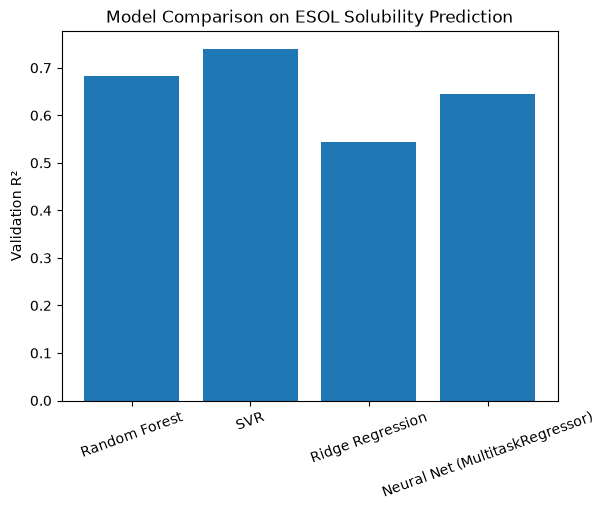

In [5]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.ylabel("Validation R²")
plt.title("Model Comparison on ESOL Solubility Prediction")
plt.xticks(rotation=20)
plt.show()